<a href="https://colab.research.google.com/github/mustafahasan12/hotel-booking-eda/blob/main/hotel_booking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('hotel_bookings.csv')

In [6]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [7]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [8]:
df.shape

(119390, 32)

In [9]:
df.drop(columns=['company'], inplace=True)

In [10]:
df['agent'] = df['agent'].fillna(
    df['agent'].median()
)

In [11]:
df['country'] = df['country'].fillna('Unknown')

In [12]:
df['children'] = df['children'].fillna(0)

In [13]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [14]:
df['adr'].isnull().sum()

np.int64(0)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [16]:
df.duplicated().sum()

np.int64(32001)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.shape

(87389, 31)

In [19]:
df['reservation_status_date'] = df['reservation_status_date'].bfill()

In [20]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,14.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,14.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,14.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [21]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [22]:
df.to_csv('cleaned_hotel_booking.csv', index=False)

In [37]:
pd.crosstab(
    df['market_segment'],
    df['is_canceled']
)

is_canceled,0,1
market_segment,,
Aviation,182,45
Complementary,614,88
Corporate,3698,510
Direct,10067,1737
Groups,3607,1335
Offline TA/TO,11826,2063
Online TA,33370,18245
Undefined,0,2


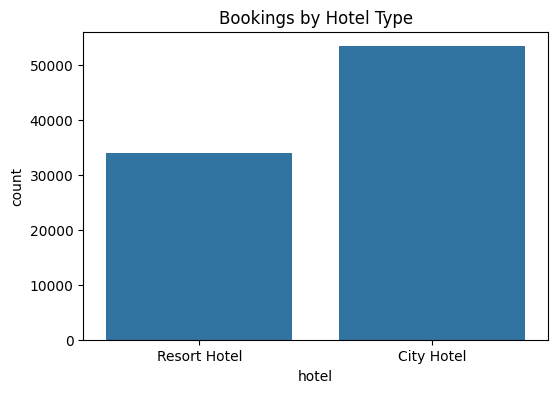

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='hotel')

plt.title('Bookings by Hotel Type')
plt.show()

* City Hotels receive a significantly higher number of bookings than Resort Hotels, indicating stronger customer demand for urban accommodations.
* This trend suggests that business travel and city tourism contribute more to total bookings.
* Hotel management should allocate more staff and resources to City Hotels during peak periods to maintain service quality.

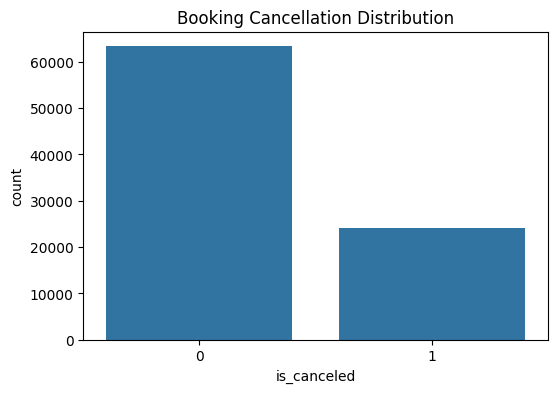

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_canceled')

plt.title('Booking Cancellation Distribution')
plt.show()

* A substantial number of bookings are cancelled, which can negatively affect occupancy rates and revenue forecasting.
* The hotel should investigate the main reasons behind cancellations and implement strategies such as flexible pricing, reminder emails, or partial prepayments.
* Reducing cancellations could improve room utilization and operational planning.

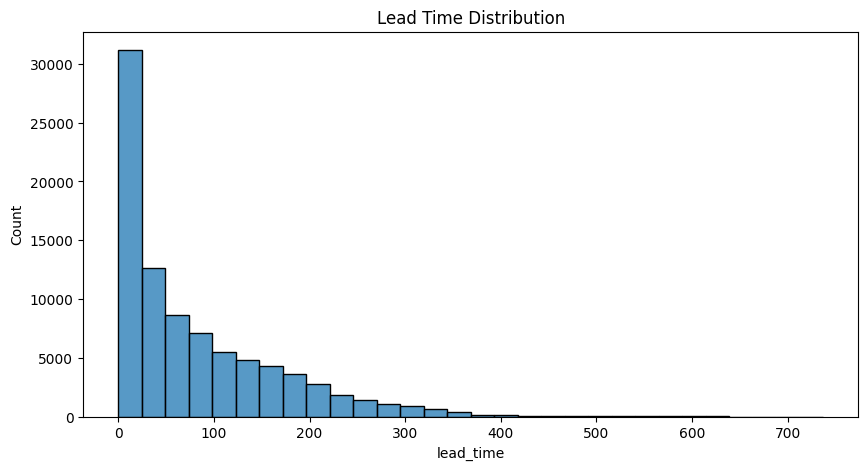

In [25]:
plt.figure(figsize=(10,5))
sns.histplot(df['lead_time'], bins=30)

plt.title('Lead Time Distribution')
plt.show()

* Most customers book their stays within a relatively short period before arrival, while a smaller group books several months in advance.
* Long booking lead times may increase the likelihood of cancellations due to changing travel plans.
* Hotels can use this information to optimize pricing strategies and promotional campaigns for early and last-minute bookings.

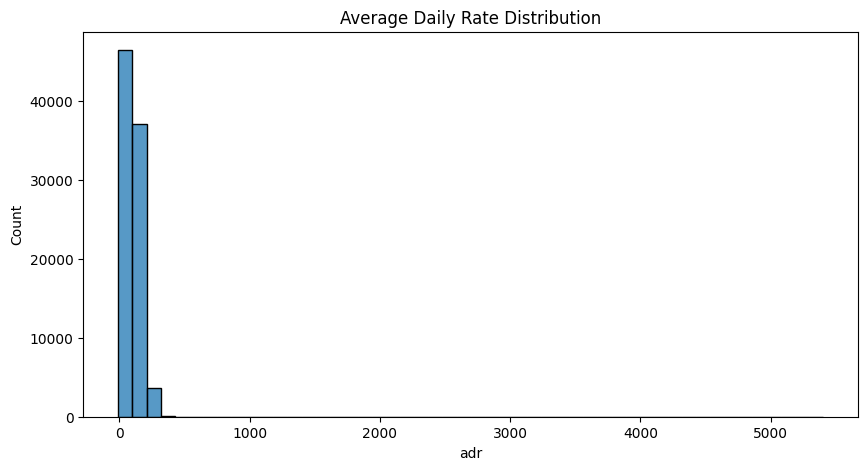

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(df['adr'], bins=50)

plt.title('Average Daily Rate Distribution')
plt.show()


* Most bookings have a moderate Average Daily Rate (ADR), while a small number of bookings have exceptionally high ADR values.
* These high-value bookings may represent premium rooms, seasonal demand, or potential outliers.
* Monitoring ADR trends helps management optimize pricing and maximize revenue.

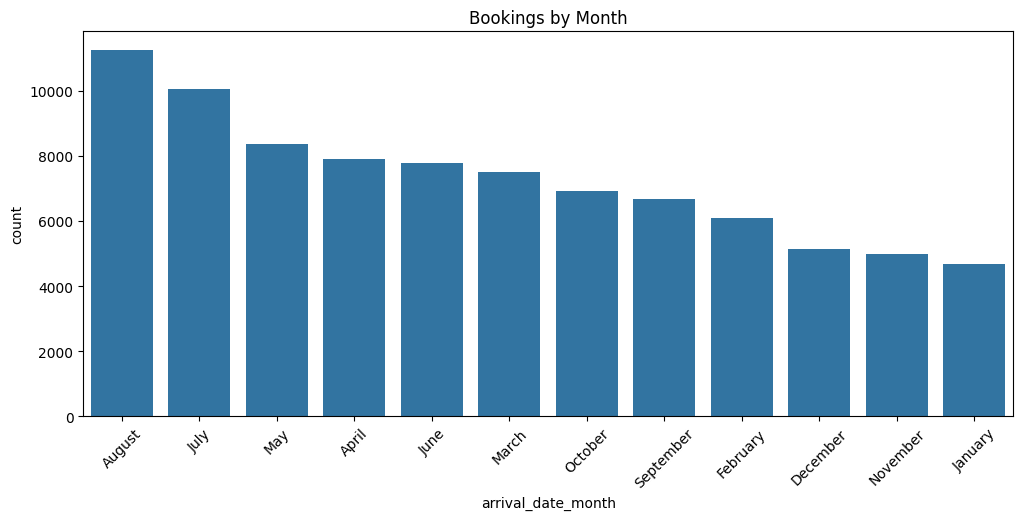

In [27]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='arrival_date_month',
    order=df['arrival_date_month'].value_counts().index
)

plt.xticks(rotation=45)
plt.title('Bookings by Month')
plt.show()

* Bookings vary considerably across months, indicating seasonal demand.
* Peak months experience significantly higher reservation volumes, while off-peak months show reduced occupancy.
* Hotels should increase staffing during busy months and introduce promotional offers during low-demand periods.

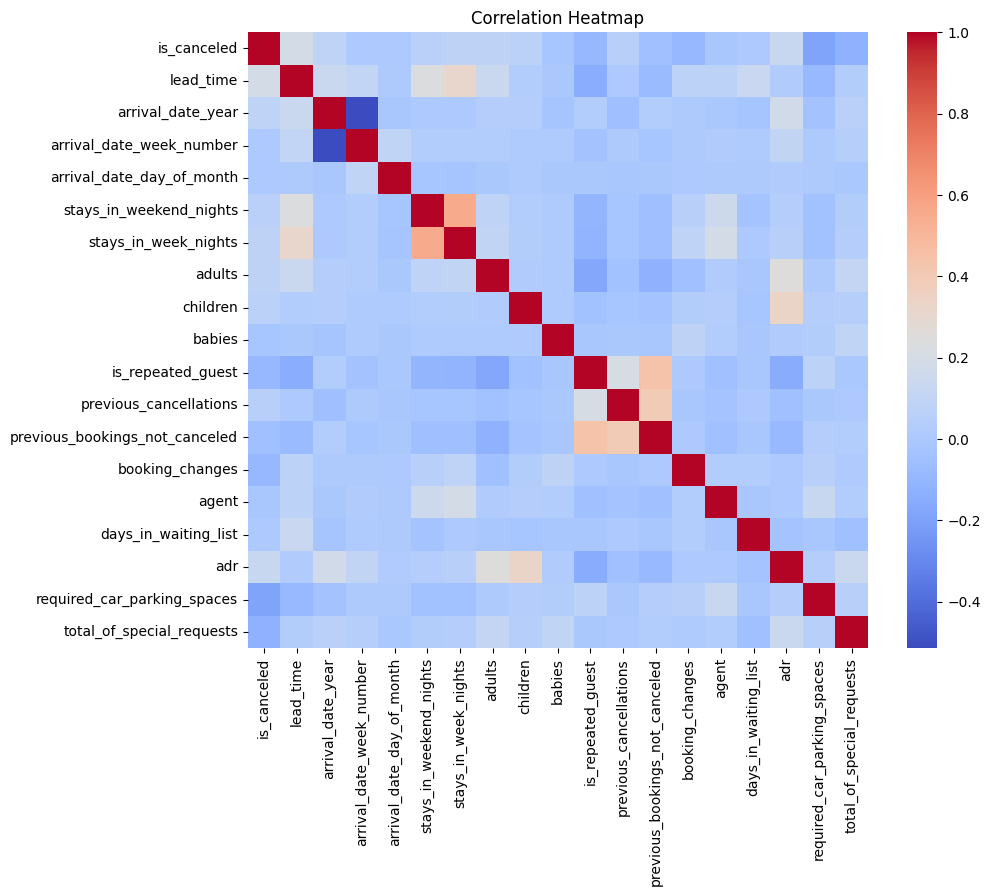

In [28]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

* Most numerical variables show weak to moderate correlations, suggesting that multiple factors influence booking behavior.
* Average Daily Rate (ADR) demonstrates stronger relationships with revenue-related metrics.
* Understanding these relationships helps identify the factors that contribute most to hotel performance.

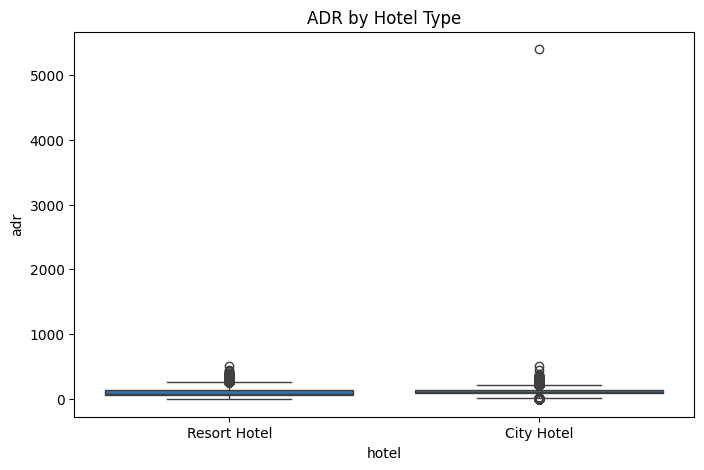

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='hotel',
    y='adr'
)

plt.title('ADR by Hotel Type')
plt.show()

* Resort Hotels generally exhibit a wider range of ADR values compared to City Hotels.
* This suggests that Resort Hotels have greater pricing flexibility, likely due to seasonal demand and premium accommodation options.
* Dynamic pricing strategies can help maximize revenue during high-demand periods.

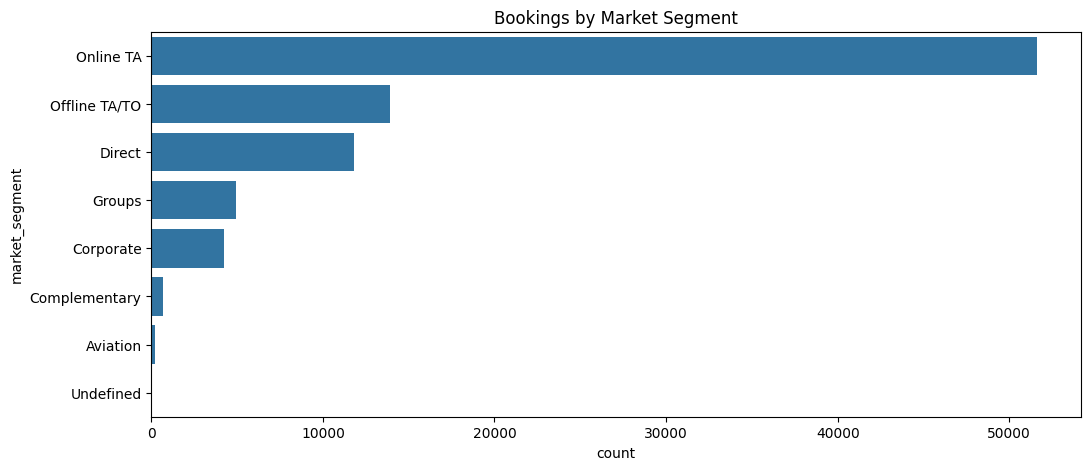

In [30]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y='market_segment',
    order=df['market_segment'].value_counts().index
)

plt.title('Bookings by Market Segment')
plt.show()

* The Online Travel Agency (OTA) segment contributes the highest number of bookings.
* This indicates that third-party booking platforms are an important source of customers.
* Maintaining strong partnerships with online travel agencies can support continued booking growth.

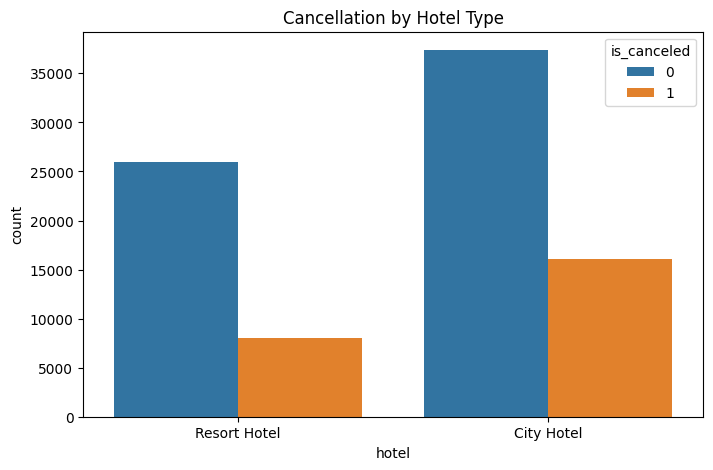

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='hotel',
    hue='is_canceled'
)

plt.title('Cancellation by Hotel Type')
plt.show()

* Cancellation rates differ between City Hotels and Resort Hotels.
* Understanding these patterns enables hotel management to develop targeted cancellation reduction strategies for each hotel type.
* Customized booking policies may help improve occupancy and revenue.

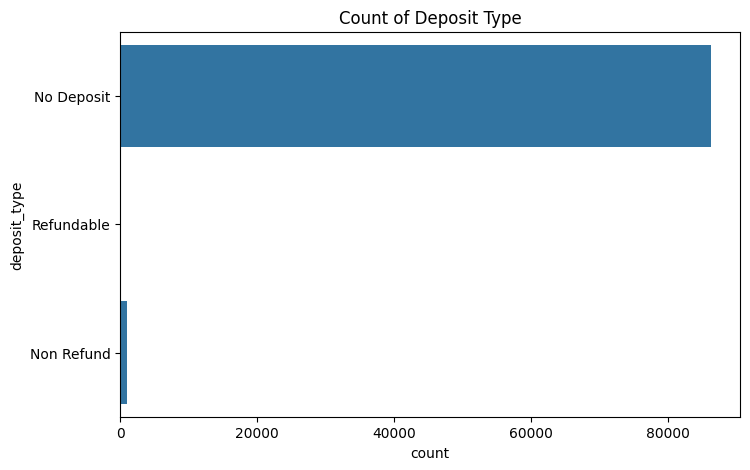

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y='deposit_type'
)

plt.title('Count of Deposit Type')
plt.show()

* Most bookings fall under the "No Deposit" category, while bookings requiring deposits represent a much smaller portion of total reservations.

* A low deposit requirement may contribute to higher booking flexibility but can also increase cancellation risk.

* Consider implementing deposit requirements for high-demand periods or customer segments with historically high cancellation rates to improve booking commitment.

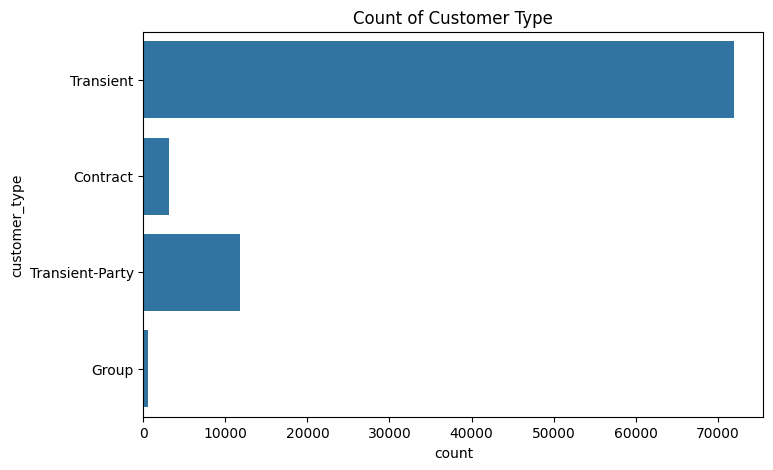

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y='customer_type'
)

plt.title('Count of Customer Type')
plt.show()

* The majority of bookings are generated by Transient customers, while Contract and Group customers represent a smaller share.

* The hotel's revenue heavily depends on individual travelers rather than long-term contracts or group bookings.

* Develop loyalty programs and personalized offers for Transient customers while exploring opportunities to increase corporate and group reservations.

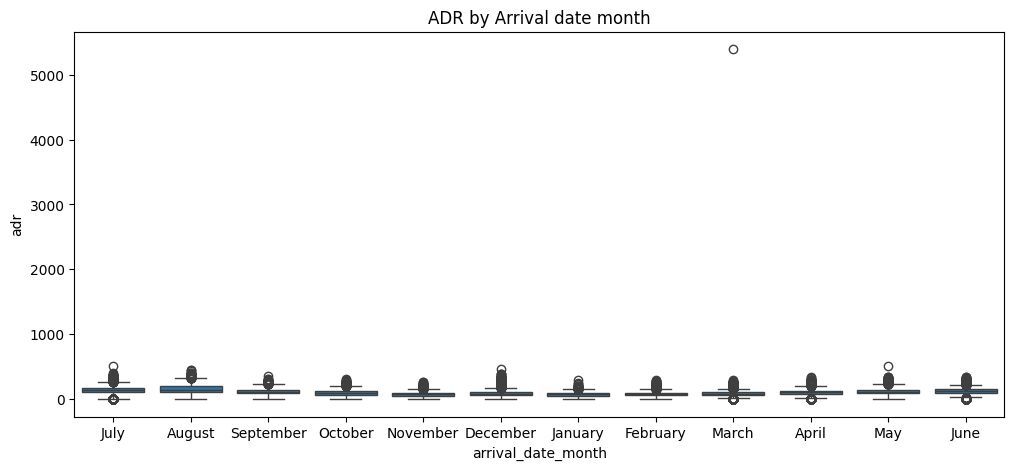

In [36]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x='arrival_date_month',
    y='adr'
)

plt.title('ADR by Arrival date month')
plt.show()

* Average Daily Rate (ADR) varies across months, with certain months showing significantly higher room prices.

* Seasonal demand directly influences hotel pricing and revenue generation.

* Implement dynamic pricing strategies to maximize revenue during peak-demand months and offer promotional discounts during low-demand periods.

# **Business Recommendations**
1. Increase staffing and room availability during peak booking months to improve customer service.
2. Investigate the primary causes of booking cancellations and introduce targeted retention strategies.
3. Focus marketing efforts on the countries that contribute the highest number of bookings.
4. Strengthen relationships with Online Travel Agencies (OTAs), as they represent the largest booking channel.
5. Implement dynamic pricing strategies to maximize Average Daily Rate (ADR) during periods of high demand.
6. Monitor pricing outliers regularly to distinguish premium bookings from potential data quality issues.